In [30]:
import importlib.util
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import seaborn as sns
custom_rqa_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "CustomRQA.py"
spec = importlib.util.spec_from_file_location("CustomRQA", str(custom_rqa_path))

CustomRQA = importlib.util.module_from_spec(spec)

spec.loader.exec_module(CustomRQA)

sys.modules["CustomRQA"] = CustomRQA

In [31]:
import CustomRQA as rqa

url = '/home/idies/workspace/RQA-and-mrDMD/Turbulence/Data/mixingdata2187.npy'
og = np.load(url)
total_t = 40.44
n_tgt = 1012
dt = total_t / (n_tgt - 1)
t = np.linspace(0, total_t, n_tgt)

print(dt, t)
original = StandardScaler().fit_transform(og)
print(original.shape)

0.04 [0.000e+00 4.000e-02 8.000e-02 ... 4.036e+01 4.040e+01 4.044e+01]
(2187, 1012)


In [33]:
dt = 0.04
window_size = int(0.1 * x.shape[0])
p = 5 # percent of RR or local niegborhood size 
print(window_size)
print(window_size//2)
# compute RQA
times = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_times.npy')

DETS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_DETS.npy')
LAMS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_LAMST.npy')
ENTRS = np.load('/home/idies/workspace/RQA-and-mrDMD/Turbulence/final_ENTRS.npy')


101
50


In [34]:
from scipy.signal import savgol_filter
DETS = savgol_filter(DETS, 50, 2)
ENTRS = savgol_filter(ENTRS, 50, 2)
LAMS = savgol_filter(LAMS, 50, 2)

In [35]:
# real‑time axes
real_times = times * dt
total_time = x.shape[0] * dt
time_axis = np.arange(x.shape[0]) * dt

regime_times = np.array([6.56, 11.4, 14.56, 20.0, 30.0])
regime_times = regime_times * (1011 / 40.44) + 1
print(regime_times)
regime_times_real = regime_times * dt
window_real = (window_size * dt)
print(window_real)

[165. 286. 365. 501. 751.]
4.04


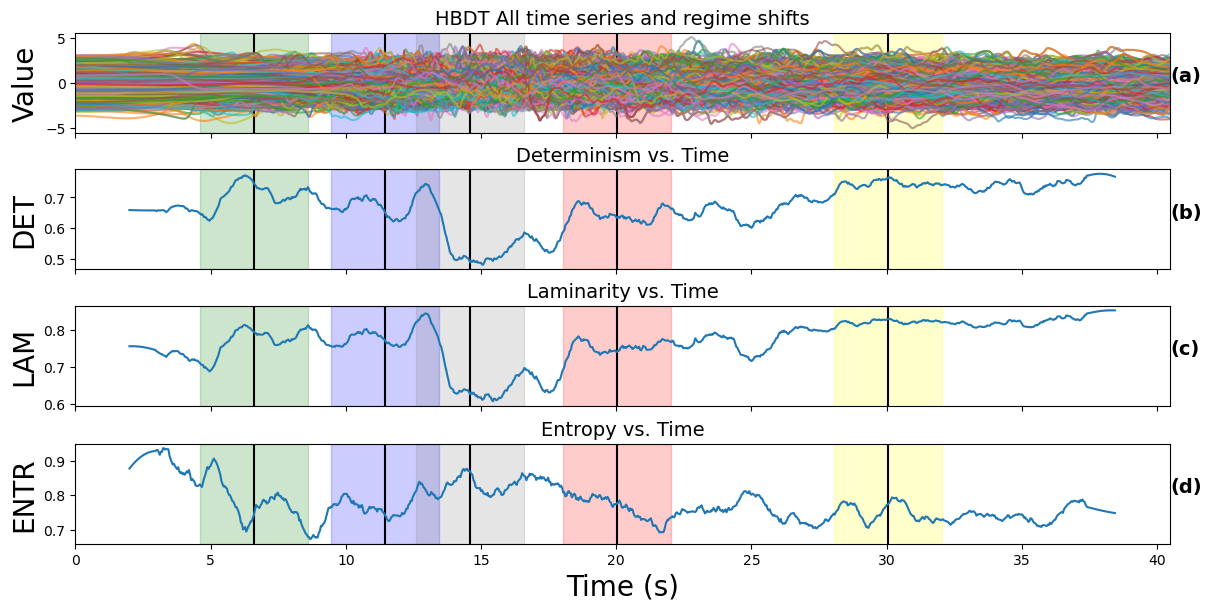

In [36]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

labels = ['(a)', '(b)', '(c)', '(d)']
regime_kwargs = dict(color='black', linestyle='solid')
i = 0 
colors = ['green', 'blue', 'gray', 'red', 'yellow']
for ax in axes:
    for t_real in regime_times_real:
        ax.axvline(t_real, **regime_kwargs)
        ax.axvspan(t_real - window_real//2, t_real + window_real//2, color=colors[i], alpha=0.2)
        i = (i+1)%5

axes[0].plot(time_axis, original.T, alpha=0.6)  
axes[0].set_ylabel('Value', fontsize=20)
axes[0].set_title('HBDT All time series and regime shifts', fontsize=14)

axes[1].plot(real_times, DETS)
axes[1].set_ylabel('DET', fontsize=20)
axes[1].set_title('Determinism vs. Time', fontsize=14)

axes[2].plot(real_times, LAMS)
axes[2].set_ylabel('LAM', fontsize=20)
axes[2].set_title('Laminarity vs. Time', fontsize=14)

axes[3].plot(real_times, ENTRS)
axes[3].set_ylabel('ENTR', fontsize=20)
axes[3].set_title('Entropy vs. Time', fontsize=14)
axes[3].set_xlabel('Time (s)', fontsize=20)
axes[3].set_xlim(0, total_time)

for ax, label in zip(axes, labels):
    ax.text(1, 0.51, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold')

plt.show()
# Metrics as dot, horizontal lines showing signifcant banbds
# Zoom in use green/blue... region colors as background 
# Try a different metrics, recurrnce network analysis
# property of node, not graph, maybe modularity (May not be useful) how string groupoings are 

# Search change point dectection https://github.com/deepcharles/ruptures
# use a differnet method or smae to try to 'quantifi' how big a transition is 

# running mean Svgol filter for blue line/ DET vs time ✅

In [ ]:
plt.plot(original[3])

In [63]:
# Need to take x and randome take points from 50 to. x.shape[0] - 50 and make a window of 10%, get that
# RP and the metrics then make a distrubution of that then do my 90, and 95 CI to find bands
import random

def get_metrics(x,n, window=.1,p=10):
    sampled_dets = []
    sampled_lams = []
    sampled_entr = []
    sampled_ratio = []
    window_size = window * x.shape[0]
    #print(x.shape)
    #start = window_size//2
    #print(start)
    end = int(x.shape[0]- int((window_size//2)*2))-1
    print(end)
    for i in range(0,n):
        random_number = random.randint(0, end)
        det = DETS[random_number]
        lam = LAMS[random_number]
        entr = ENTRS[random_number]

        '''
                block = x[int(random_number-window_size//2): int(random_number+window_size//2)]
        metrics,_ = rqa.RecurrencePlot(block, percent=p, metric ='euclidean', globalEpsilon=True)
        det = metrics['DET']
        lam = metrics['LAM']
        entr = metrics['ENTR']
        '''
        sampled_dets.append(det)
        sampled_lams.append(lam)
        sampled_entr.append(entr)
    return sampled_dets, sampled_lams, sampled_entr
sampled_dets, sampled_lams, sampled_entr = get_metrics(x,10000)

911


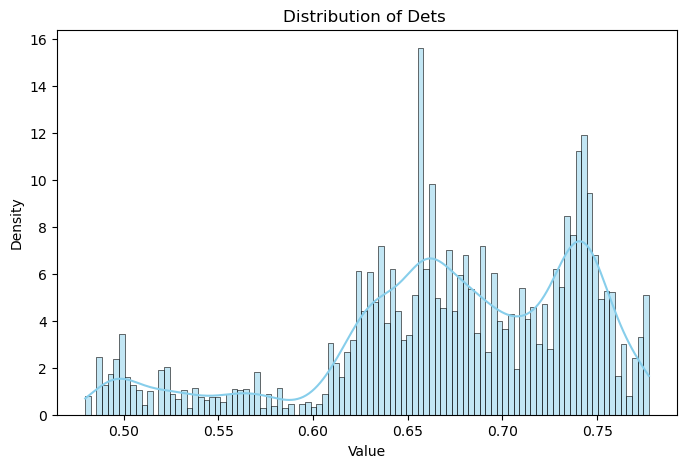

0.5152831341744225 0.7591207815799558


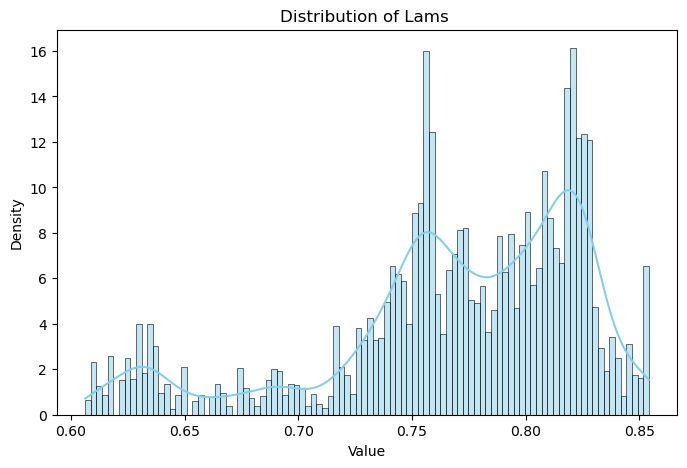

0.6349822201289882 0.8349631805236872


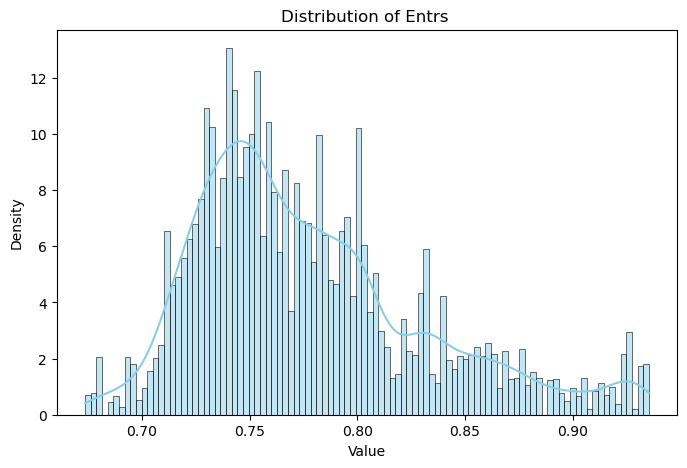

0.7114571128023403 0.8887746882146086


(0.7114571128023403, 0.8887746882146086)

In [64]:
def bootstrap_ci(sampled_metric,n,alpha=0.05,plot=False, metric_name=''):
    if plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(sampled_metric, bins=len(sampled_metric)//100, kde=True, stat="density", color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {metric_name} ")
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.show()
    lo, hi = np.percentile(sampled_metric, [100*alpha/2, 100*(1-alpha/2)])
    print(lo,hi)
    return lo,hi
alpha=0.1
bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')


0.7114571128023403 0.8887746882146086


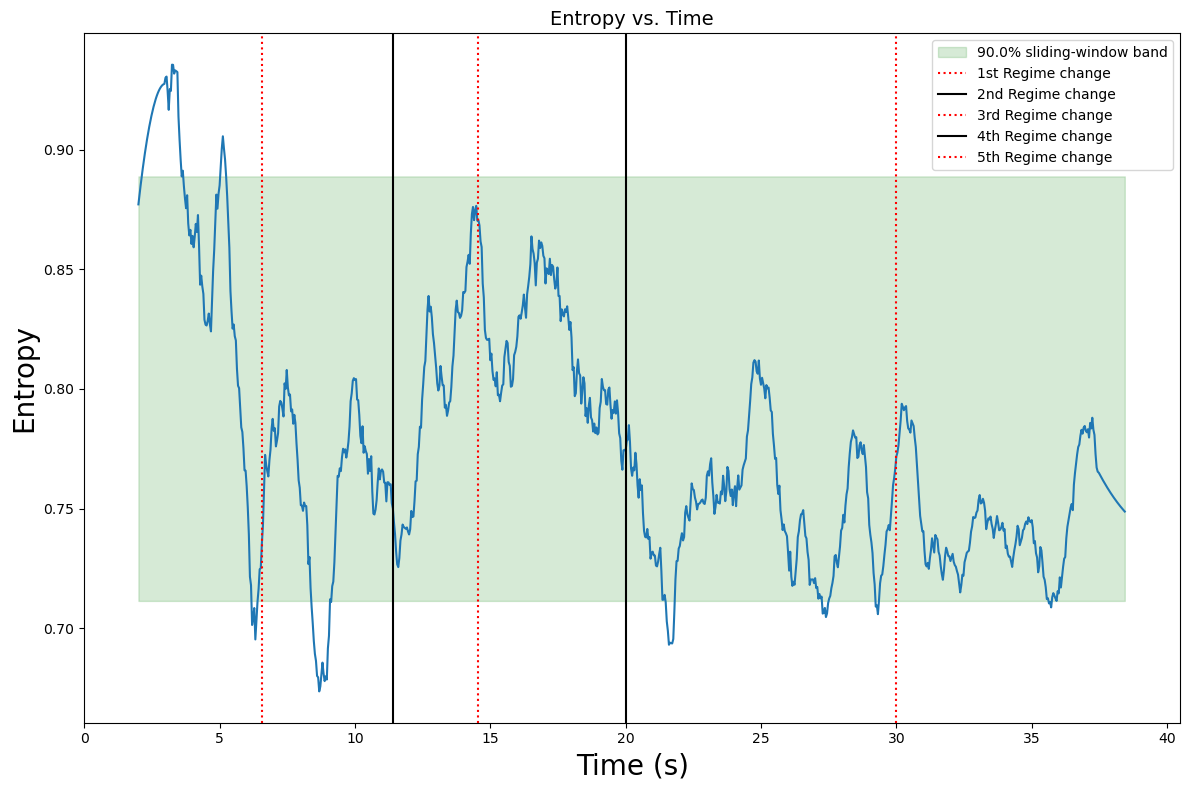

0.1


In [65]:
def plotting(metric, metric_name, lo,hi, percent):
    plt.figure(figsize=(12,8))
    plt.plot(real_times, metric)
    plt.ylabel(f'{metric_name}', fontsize=20)
    plt.title(f'{metric_name} vs. Time', fontsize=14)
    plt.xlabel('Time (s)', fontsize=20)
    plt.xlim(0, total_time)
    plt.fill_between(real_times, lo, hi, alpha=0.16, label=f'{100-percent}% sliding-window band', zorder=1, color='green')
    plt.axvline(6.56, color='red', linestyle='dotted', label='1st Regime change')
    plt.axvline(11.4, color='Black', linestyle='solid', label='2nd Regime change')
    plt.axvline(14.56, color='red', linestyle='dotted', label='3rd Regime change')
    plt.axvline(20, color='Black', linestyle='solid', label='4th Regime change')
    plt.axvline(30, color='red', linestyle='dotted', label='5th Regime change')
    plt.tight_layout()
    plt.legend()
    plt.show()
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=False,metric_name='Entropy')
'''
mean = np.mean(ENTRS)
std = np.std(ENTRS)
print(mean,std)
lo = mean - std
hi = mean + std
'''
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)
print(alpha)


0.5152831341744225 0.7591207815799558


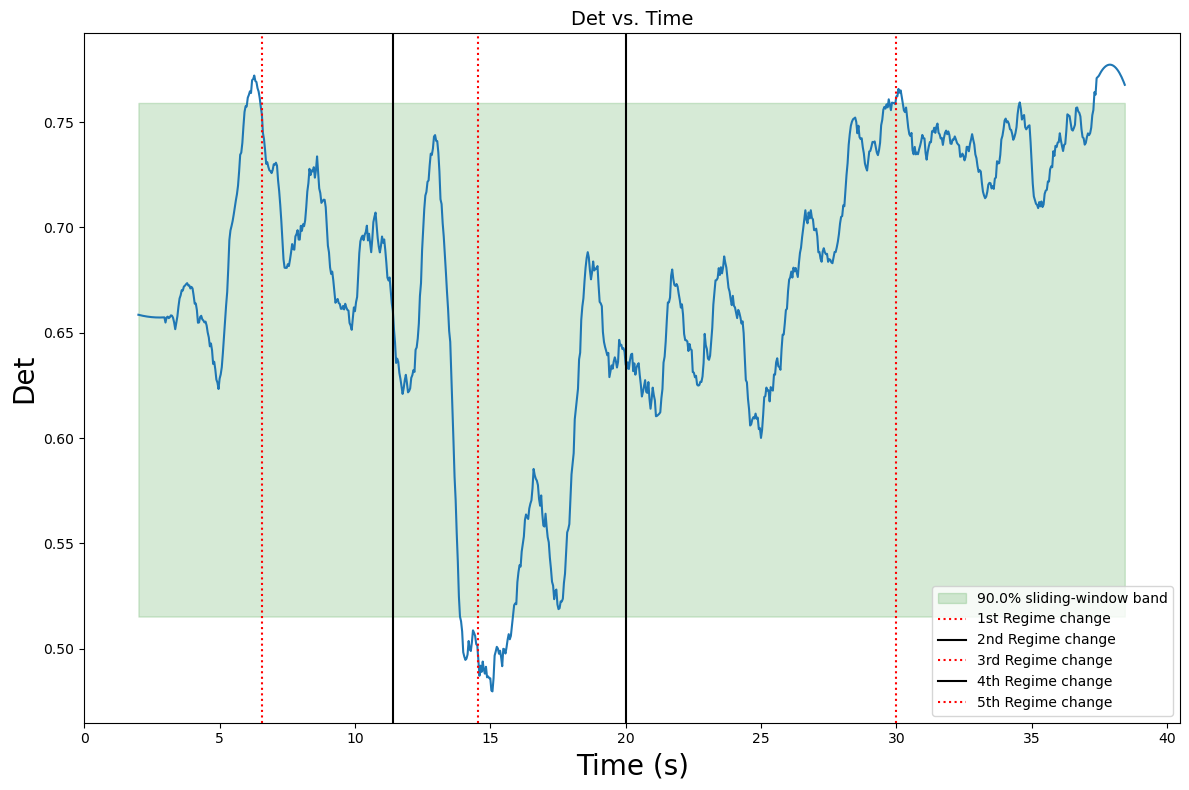

In [66]:
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=False,metric_name='')
plotting(DETS, 'Det', lo,hi, alpha*100)

0.6349822201289882 0.8349631805236872


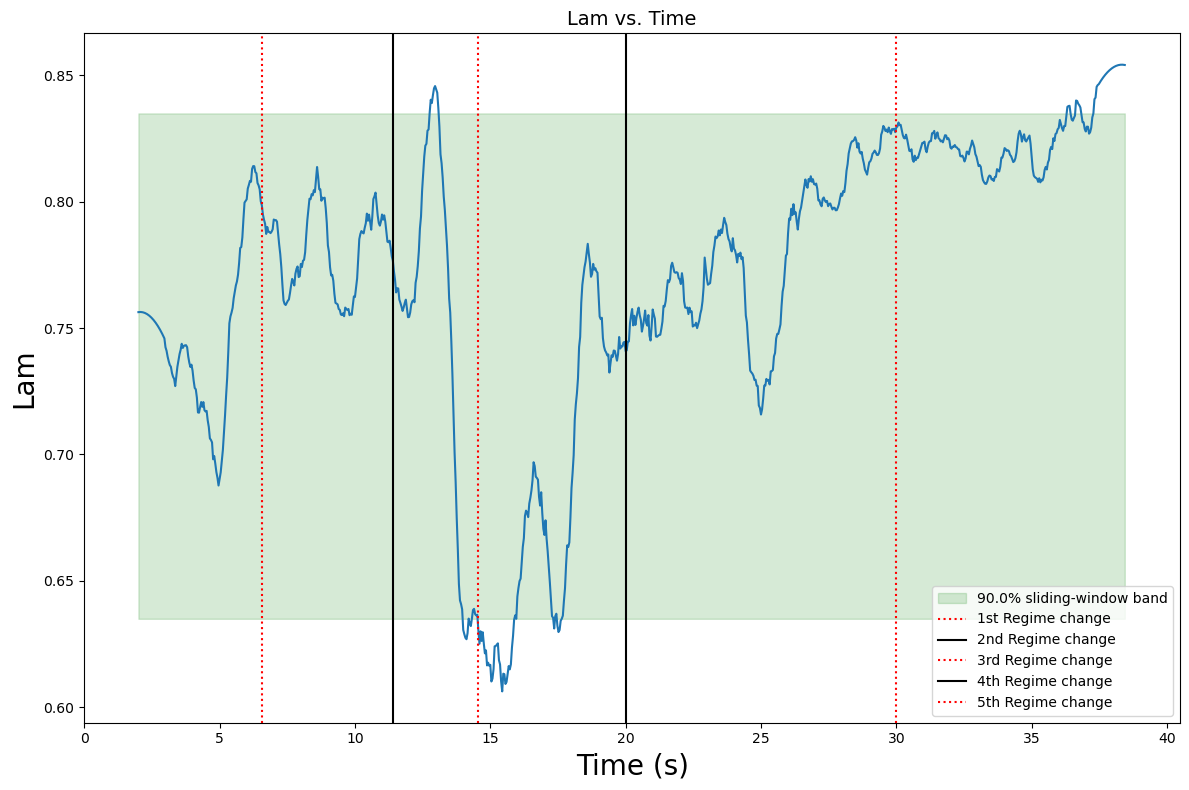

In [67]:
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=False,metric_name='')
plotting(LAMS, 'Lam', lo,hi, alpha*100)

0.8444444444444444 0.9506578947368421


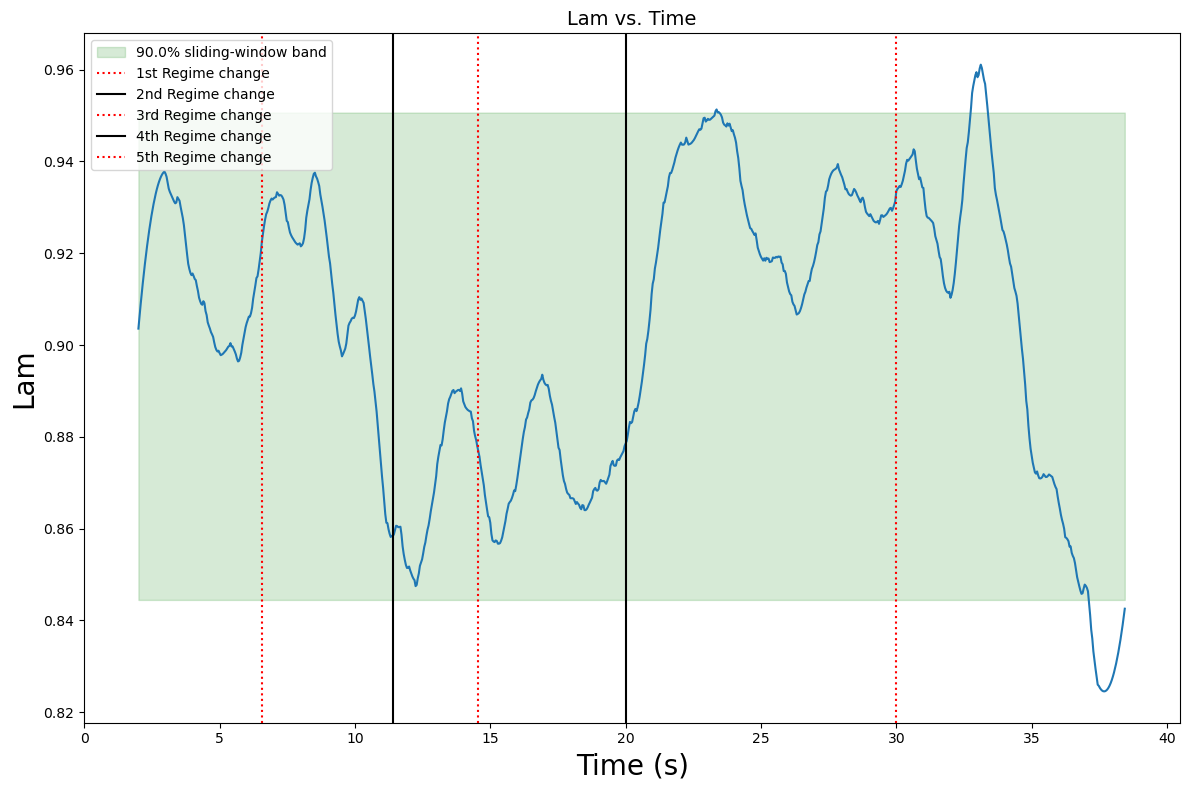

In [15]:
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=False,metric_name='')
plotting(LAMS, 'Lam', lo,hi, alpha*100)

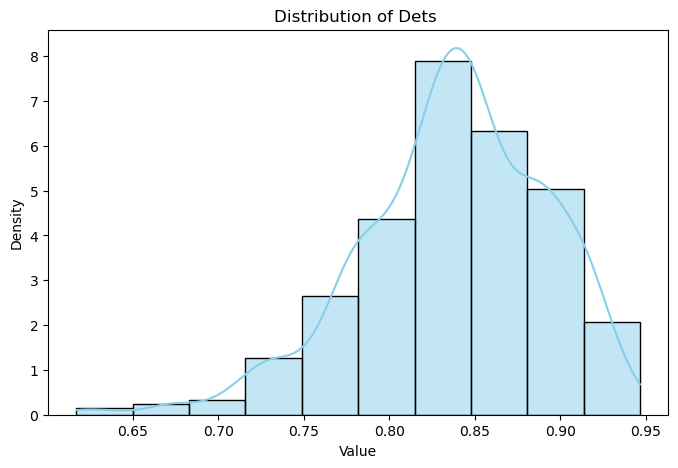

0.7177777777777777 0.9224032442010152


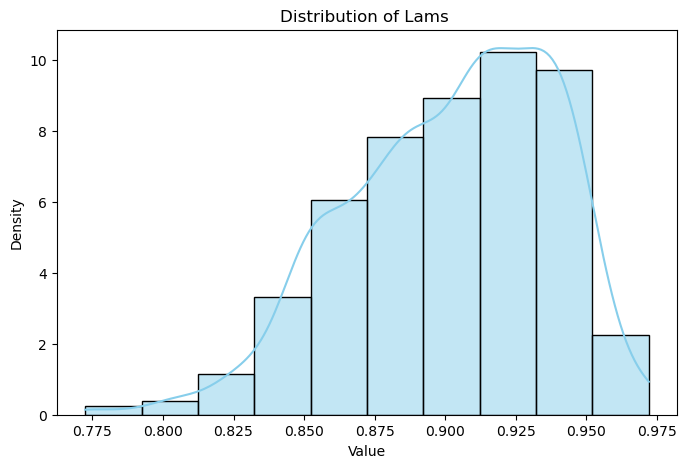

0.8244444444444444 0.9566666666666667


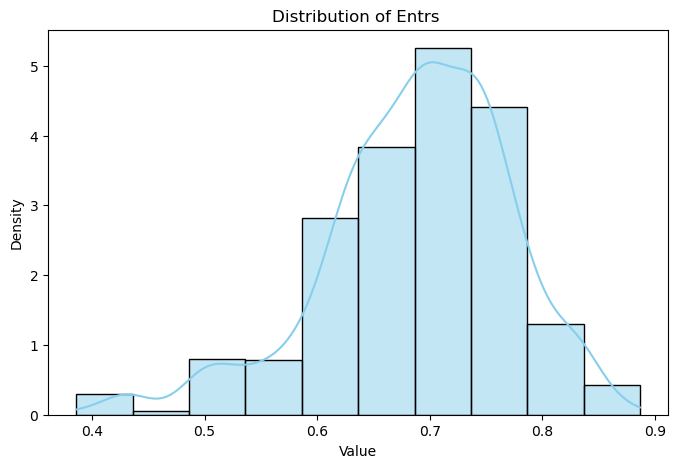

0.4925138970300002 0.8302315245083395
0.4925138970300002 0.8302315245083395


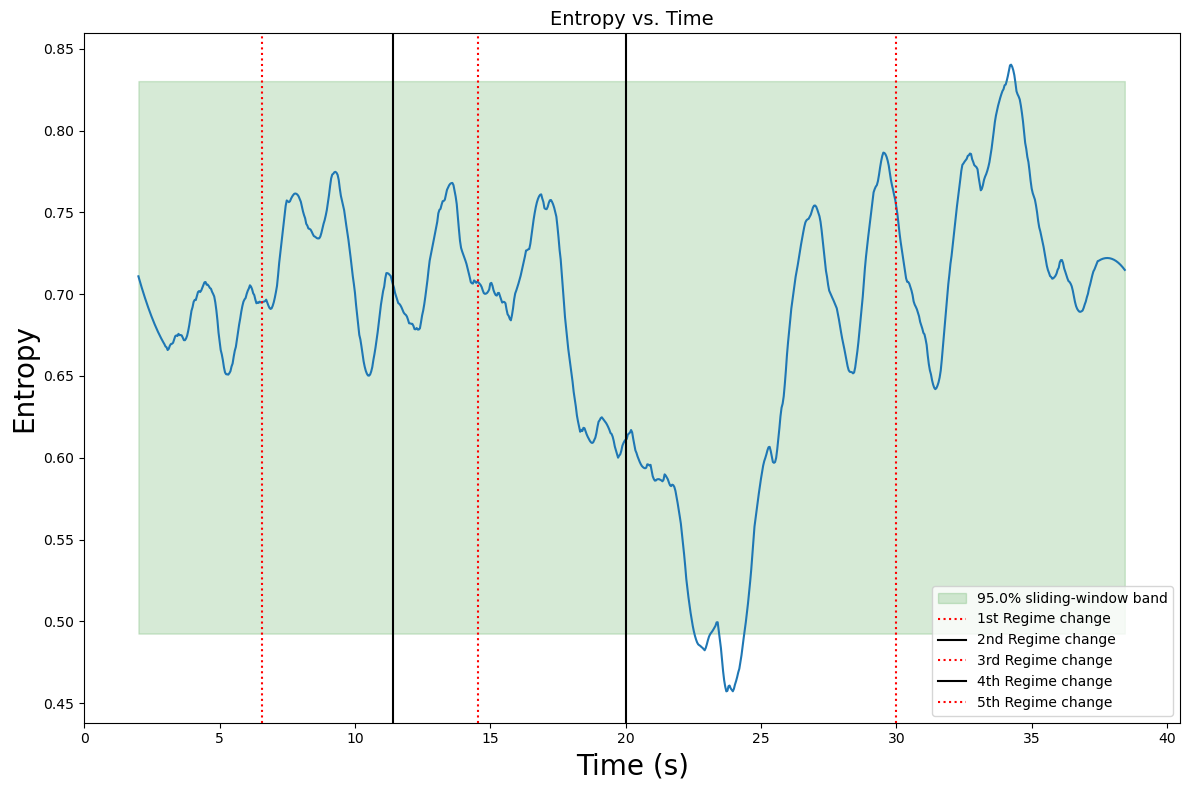

0.05
0.7177777777777777 0.9224032442010152


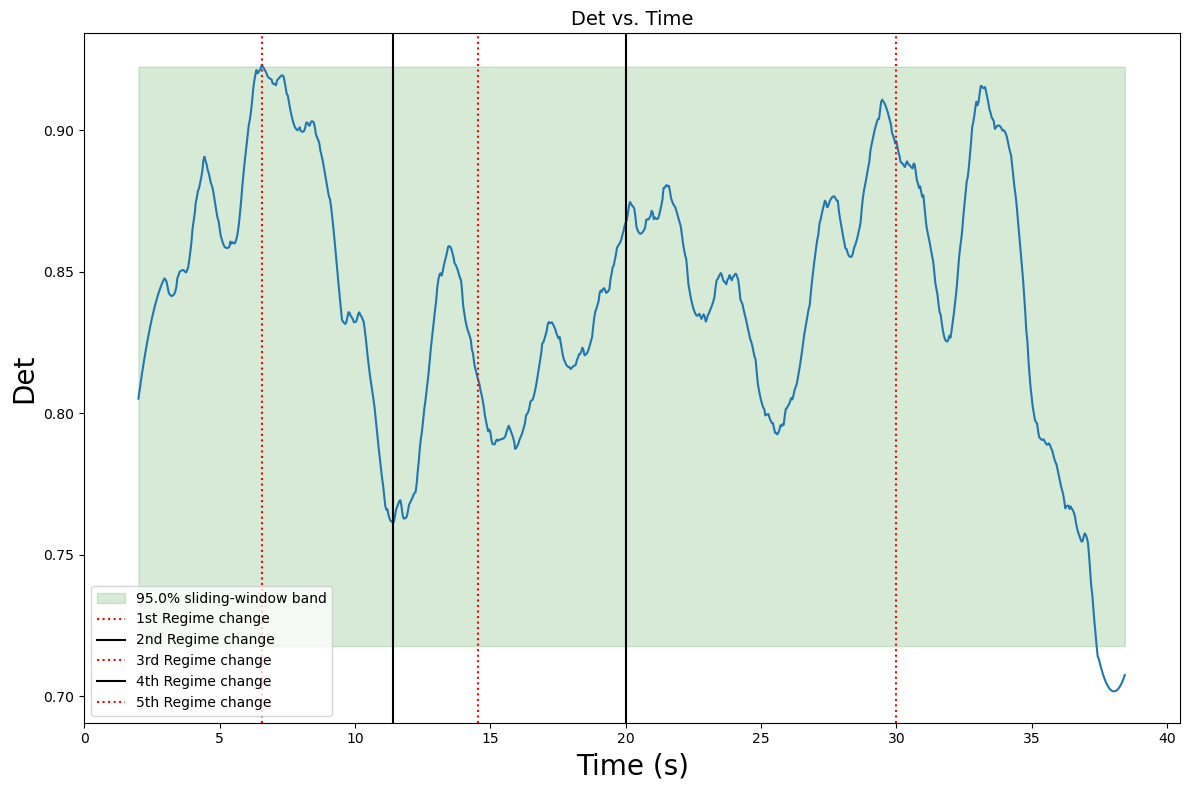

0.8244444444444444 0.9566666666666667


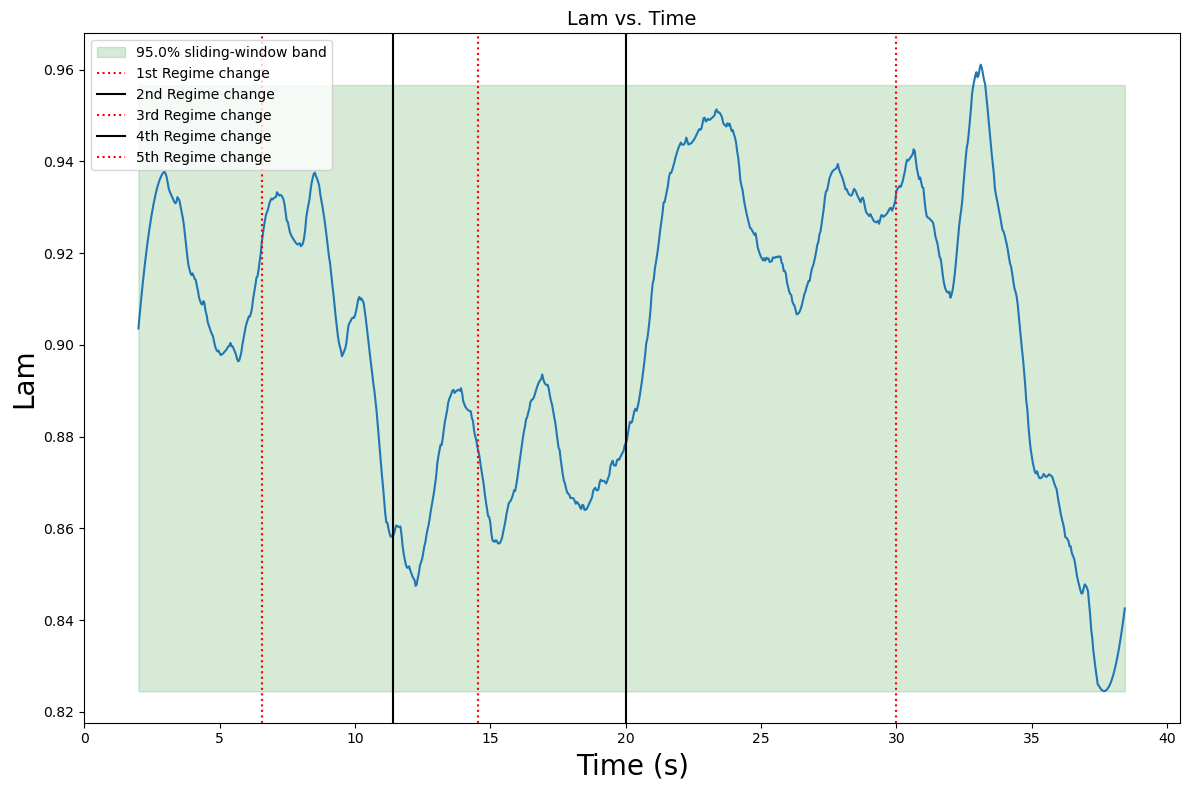

In [16]:
alpha=0.05
bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')

lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=False,metric_name='Entropy')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)
print(alpha)

lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=False,metric_name='')
plotting(DETS, 'Det', lo,hi, alpha*100)


lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=False,metric_name='')
plotting(LAMS, 'Lam', lo,hi, alpha*100)

In [ ]:
!pip install ruptures

In [ ]:
import matplotlib.pyplot as plt
import ruptures as rpt
algo = rpt.Pelt(model="rbf").fit(DETS)
result = algo.predict(pen=10)
rpt.display(DETS, result)
plt.show()

In [ ]:
algo = rpt.Pelt(model="rbf").fit(LAMS)
result = algo.predict(pen=10)
rpt.display(LAMS, result)
plt.show()

In [ ]:
algo = rpt.Pelt(model="rbf").fit(ENTRS)
result = algo.predict(pen=10)
rpt.display(ENTRS, result)
plt.show()

In [ ]:
ts = original[3]
algo = rpt.Pelt(model="rbf").fit(ts)
result = algo.predict(pen=25)
print(result)
rpt.display(ts, result)
plt.show()

In [ ]:
sample = np.random.choice(ENTRS, size=sample_amount, replace=False)
plt.figure(figsize=(8, 5))
sns.histplot(sample, bins=50, kde=True, stat="density", color="skyblue", edgecolor="black")
plt.title(f"Distribution of ENTRS (Sampled {sample_percent*100:.0f}%)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

regime_idxs = np.array([165, 286, 365, 501, 751]).astype(int)

start_of_times = int(times[0])   
N = len(ENTRS)
starts = [start_of_times] + list((regime_idxs + 1).astype(int))
ends   = list(regime_idxs.astype(int)) + [N-1]

segments = list(zip(starts, ends))
regions = [ENTRS[s:e+1] for s, e in segments]

means, lows, highs = [], [], []
for i, (s, e) in enumerate(segments):
    est, lo, hi = bootstrap_ci(regions[i], statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0+i)
    means.append(est)
    lows.append(lo)
    highs.append(hi)
    print(f"Region {i}: indices {s}:{e}  (n={len(regions[i])})")
    print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

x = range(len(regions))
err_lower = [m - l for m, l in zip(means, lows)]
err_upper = [h - m for m, h in zip(means, highs)]

plt.figure(figsize=(8, 4))
plt.errorbar(x, means, yerr=[err_lower, err_upper], fmt='o', capsize=4, color="darkred")
plt.xticks(x)
plt.xlabel("Region index")
plt.ylabel("Mean")
plt.title("Regime-based region means with 95% bootstrap CI")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
window_size_regions = int(.05 * len(ENTRS))
regions = [ENTRS[i:i+window_size_regions] for i in range(0, len(ENTRS), window_size_regions)]

means, lows, highs = [], [], []
for i, s in enumerate(range(0, len(ENTRS), window_size_regions)):
    e = min(len(ENTRS) - 1, s + window_size_regions - 1)
    est, lo, hi = bootstrap_ci(regions[i], statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0+i)
    means.append(est)
    lows.append(lo)
    highs.append(hi)
    print(f"Region {i}: indices {s}:{e}  (n={len(regions[i])})")
    print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

x = range(len(regions))
err_lower = [m - l for m, l in zip(means, lows)]
err_upper = [h - m for m, h in zip(means, highs)]

plt.figure(figsize=(8, 4))
plt.errorbar(x, means, yerr=[err_lower, err_upper], fmt='o', capsize=4, color="navy")
plt.xticks(x)
plt.xlabel("Region index")
plt.ylabel("Mean")
plt.title("Window-based region means with 95% bootstrap CI")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# window_size_regions = int(.1 * len(ENTRS)) regions = [ENTRS[i:i+window_size_regions] for i in range(0, len(ENTRS), window_size_regions)] for i, s in enumerate(range(0, len(ENTRS), window_size_regions)): e = min(len(ENTRS) - 1, s + window_size_regions - 1) print(f"Region {i}: indices {s}:{e} (n={len(regions[i])})") for i, reg in enumerate(regions): est, lo, hi = bootstrap_ci(reg, statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0) print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

In [ ]:
window_size = int(.05 * len(ENTRS))

# pick step size so we get ~50 windows
n_windows_target = 200
step = max(1, (len(ENTRS) - window_size) // n_windows_target)

regions = [ENTRS[i:i+window_size] for i in range(0, len(ENTRS) - window_size + 1, step)]

means, lows, highs = [], [], []
for i, start in enumerate(range(0, len(ENTRS) - window_size + 1, step)):
    s = start
    e = s + window_size - 1
    est, lo, hi = bootstrap_ci(regions[i], statfunc=np.mean, n_boot=2000, alpha=0.05, seed=0+i)
    means.append(est)
    lows.append(lo)
    highs.append(hi)
    print(f"Region {i}: indices {s}:{e}  (n={len(regions[i])})")
    print(f"Region {i} mean={est:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")

# Error bars
x = range(len(regions))
err_lower = [m - l for m, l in zip(means, lows)]
err_upper = [h - m for m, h in zip(means, highs)]

plt.figure(figsize=(10, 5))
plt.errorbar(x, means, yerr=[err_lower, err_upper], fmt='o', capsize=3, color="navy")
plt.xlabel("Window index")
plt.ylabel("Mean")
plt.title("Sliding-window and resampling means with 95% bootstrap CI")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

window_size = int(.05 * len(ENTRS))            # 10% window
n_boot = 2000
alpha95 = 0.05
alpha90 = 0.10

starts = list(range(0, len(ENTRS) - window_size + 1, 1))
n_windows = len(starts)
print("window_size:", window_size, "n_windows:", n_windows)

lo95_list = np.zeros(n_windows)
hi95_list = np.zeros(n_windows)
lo90_list = np.zeros(n_windows)
hi90_list = np.zeros(n_windows)
means_list = np.zeros(n_windows)

for i, s in enumerate(starts):
    e = s + window_size - 1
    region = ENTRS[s:e+1]
    est, lo95, hi95 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha95, seed=1000 + i)
    _, lo90, hi90 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha90, seed=2000 + i)
    means_list[i] = est
    lo95_list[i] = lo95
    hi95_list[i] = hi95
    lo90_list[i] = lo90
    hi90_list[i] = hi90

    if (i + 1) % 200 == 0 or (i + 1) == n_windows:
        print(f"Computed window {i+1}/{n_windows}  (indices {s}:{e})")

N = len(ENTRS)
lower95_sum = np.zeros(N)
upper95_sum = np.zeros(N)
lower90_sum = np.zeros(N)
upper90_sum = np.zeros(N)
counts = np.zeros(N, dtype=int)

for i, s in enumerate(starts):
    e = s + window_size - 1
    lower95_sum[s:e+1] += lo95_list[i]
    upper95_sum[s:e+1] += hi95_list[i]
    lower90_sum[s:e+1] += lo90_list[i]
    upper90_sum[s:e+1] += hi90_list[i]
    counts[s:e+1] += 1

counts_safe = counts.copy().astype(float)
counts_safe[counts_safe == 0] = 1.0

lower95 = lower95_sum / counts_safe
upper95 = upper95_sum / counts_safe
lower90 = lower90_sum / counts_safe
upper90 = upper90_sum / counts_safe

print("counts coverage: min", counts.min(), "max", counts.max(), "mean", counts.mean())



In [ ]:
ENTRS = np.asarray(ENTRS)
times_arr = np.asarray(times)   

mask90 = (ENTRS < lower90) | (ENTRS > upper90)
mask95 = (ENTRS < lower95) | (ENTRS > upper95)

idx90 = np.nonzero(mask90)[0].astype(int)
idx95 = np.nonzero(mask95)[0].astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

ax1.fill_between(times_arr, lower90, upper90, alpha=0.16, label='90% sliding-window band', zorder=1, color='green')
ax1.plot(times_arr, ENTRS, linewidth=1, label='ENTRS', zorder=5)
ax1.set_xlabel('Time')
ax1.set_ylabel('ENTRS')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.fill_between(times_arr, lower95, upper95, alpha=0.12, label='95% sliding-window band', zorder=1, color='green')
ax2.plot(times_arr, ENTRS, linewidth=1, label='ENTRS', zorder=5)
ax2.set_title('ENTRS vs Time — 95% sliding-window band')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Points outside 90% band: {len(idx90)}")

print(f"Points outside 90% band percent : {len(idx90)/ len(ENTRS) }")
print(f"Points outside 95% band: {len(idx95)}")
print(f"Points outside 95% band percent : {len(idx95)/ len(ENTRS) }")



In [ ]:
window_size = int(.05 * len(DETS))            # 10% window
n_boot = 2000
alpha95 = 0.05
alpha90 = 0.10

starts = list(range(0, len(DETS) - window_size + 1, 1))
n_windows = len(starts)
print("window_size:", window_size, "n_windows:", n_windows)

lo95_list = np.zeros(n_windows)
hi95_list = np.zeros(n_windows)
lo90_list = np.zeros(n_windows)
hi90_list = np.zeros(n_windows)
means_list = np.zeros(n_windows)

for i, s in enumerate(starts):
    e = s + window_size - 1
    region = DETS[s:e+1]
    est, lo95, hi95 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha95, seed=1000 + i)
    _, lo90, hi90 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha90, seed=2000 + i)
    means_list[i] = est
    lo95_list[i] = lo95
    hi95_list[i] = hi95
    lo90_list[i] = lo90
    hi90_list[i] = hi90


N = len(DETS)
lower95_sum = np.zeros(N)
upper95_sum = np.zeros(N)
lower90_sum = np.zeros(N)
upper90_sum = np.zeros(N)
counts = np.zeros(N, dtype=int)

for i, s in enumerate(starts):
    e = s + window_size - 1
    lower95_sum[s:e+1] += lo95_list[i]
    upper95_sum[s:e+1] += hi95_list[i]
    lower90_sum[s:e+1] += lo90_list[i]
    upper90_sum[s:e+1] += hi90_list[i]
    counts[s:e+1] += 1


counts_safe = counts.copy().astype(float)
counts_safe[counts_safe == 0] = 1.0

lower95 = lower95_sum / counts_safe
upper95 = upper95_sum / counts_safe
lower90 = lower90_sum / counts_safe
upper90 = upper90_sum / counts_safe


DETS = np.asarray(DETS)
times_arr = np.asarray(times)   

mask90 = (DETS < lower90) | (DETS > upper90)
mask95 = (DETS < lower95) | (DETS > upper95)

idx90 = np.nonzero(mask90)[0].astype(int)
idx95 = np.nonzero(mask95)[0].astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# 90% plot
ax1.fill_between(times_arr, lower90, upper90, alpha=0.16, label='90% sliding-window band', zorder=1, color='green')
ax1.plot(times_arr, DETS, linewidth=1, label='DETS', zorder=5)
ax1.set_xlabel('Time')
ax1.set_ylabel('DETS')
ax1.grid(alpha=0.25)
ax1.legend()

# 95% plot
ax2.fill_between(times_arr, lower95, upper95, alpha=0.12, label='95% sliding-window band', zorder=1, color='green')
ax2.plot(times_arr, DETS, linewidth=1, label='DETS', zorder=5)
ax2.set_title('DETS vs Time — 95% sliding-window band')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Points outside 90% band: {len(idx90)}")

print(f"Points outside 90% band percent : {len(idx90)/ len(DETS) }")
print(f"Points outside 95% band: {len(idx95)}")
print(f"Points outside 95% band percent : {len(idx95)/ len(DETS) }")



In [ ]:
window_size = int(.05 * len(LAMS))            
n_boot = 2000
alpha95 = 0.05
alpha90 = 0.10

starts = list(range(0, len(LAMS) - window_size + 1, 1))
n_windows = len(starts)
print("window_size:", window_size, "n_windows:", n_windows)

lo95_list = np.zeros(n_windows)
hi95_list = np.zeros(n_windows)
lo90_list = np.zeros(n_windows)
hi90_list = np.zeros(n_windows)
means_list = np.zeros(n_windows)

for i, s in enumerate(starts):
    e = s + window_size - 1
    region = LAMS[s:e+1]
    est, lo95, hi95 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha95, seed=1000 + i)
    _, lo90, hi90 = bootstrap_ci(region, statfunc=np.mean, n_boot=n_boot, alpha=alpha90, seed=2000 + i)
    means_list[i] = est
    lo95_list[i] = lo95
    hi95_list[i] = hi95
    lo90_list[i] = lo90
    hi90_list[i] = hi90


N = len(LAMS)
lower95_sum = np.zeros(N)
upper95_sum = np.zeros(N)
lower90_sum = np.zeros(N)
upper90_sum = np.zeros(N)
counts = np.zeros(N, dtype=int)

for i, s in enumerate(starts):
    e = s + window_size - 1
    lower95_sum[s:e+1] += lo95_list[i]
    upper95_sum[s:e+1] += hi95_list[i]
    lower90_sum[s:e+1] += lo90_list[i]
    upper90_sum[s:e+1] += hi90_list[i]
    counts[s:e+1] += 1


counts_safe = counts.copy().astype(float)
counts_safe[counts_safe == 0] = 1.0

lower95 = lower95_sum / counts_safe
upper95 = upper95_sum / counts_safe
lower90 = lower90_sum / counts_safe
upper90 = upper90_sum / counts_safe




LAMS = np.asarray(LAMS)
times_arr = np.asarray(times)   

mask90 = (LAMS < lower90) | (LAMS > upper90)
mask95 = (LAMS < lower95) | (LAMS > upper95)

idx90 = np.nonzero(mask90)[0].astype(int)
idx95 = np.nonzero(mask95)[0].astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# 90% plot
ax1.fill_between(times_arr, lower90, upper90, alpha=0.16, label='90% sliding-window band', zorder=1, color='green')
ax1.plot(times_arr, LAMS, linewidth=1, label='LAMS', zorder=5)
ax1.set_xlabel('Time')
ax1.set_ylabel('LAMS')
ax1.grid(alpha=0.25)
ax1.legend()

# 95% plot
ax2.fill_between(times_arr, lower95, upper95, alpha=0.12, label='95% sliding-window band', zorder=1, color='green')
ax2.plot(times_arr, LAMS, linewidth=1, label='LAMS', zorder=5)
ax2.set_title('LAMS vs Time — 95% sliding-window band')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Points outside 90% band: {len(idx90)}")

print(f"Points outside 90% band percent : {len(idx90)/ len(LAMS) }")
print(f"Points outside 95% band: {len(idx95)}")
print(f"Points outside 95% band percent : {len(idx95)/ len(LAMS) }")


In [ ]:
print(original.T.shape)

In [ ]:
dt = 0.04
window_size = int(0.1 * original.shape[1])
print(window_size)
p = 10
temp = original.T
print(temp.shape)
times, D, L, E = rqa.sliding_window_rqa(
    temp, p, metric='euclidean', q=1,
    window_size=window_size, step=1,
    l_min=2, v_min=2, globalEpsilon=False
)

In [ ]:
print((L))

In [ ]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
axes[0].plot(temp)  

axes[1].plot(D)


axes[2].plot(L)


axes[3].plot( E)


In [ ]:
dt = 0.04
window_size = int(0.1 * original.shape[1])
print(window_size)
p = 10
temp = original[800:801].T
print(temp.shape)
times, D, L, E = rqa.sliding_window_rqa(
    temp, p, metric='euclidean', q=1,
    window_size=window_size, step=1,
    l_min=2, v_min=2, globalEpsilon=False
)


fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
axes[0].plot(temp)  

axes[1].plot(D)


axes[2].plot(L)


axes[3].plot( E)

In [ ]:
# 